# Week 1 · Notebook 2 — Representations, Neighbourhoods and Local Search

**Goals**
- Define representations (binary, real-valued, permutation) and genotype–phenotype maps (binary decoding,
  random keys), and the neighbourhood structures on them (bit flip, swap, insertion, 2-opt, Gaussian step).
- Derive neighbourhood sizes and verify them by explicit enumeration.
- Define local optimality *relative to a neighbourhood*; implement first- and best-improvement hill climbing.
- Validate 2-opt local search for the TSP against the exact Held–Karp optimum: % above optimum and rate of
  hitting the optimum, over many instances and starts.
- Compare random search and random-restart hill climbing at equal evaluation budgets.
- Measure basins of attraction **exhaustively** on a 14-bit instance and predict the success rate of random restarts.
- Show Hamming cliffs of standard binary coding and why Gray coding removes the false optima of 1-D unimodal functions.

**Prerequisites:** Notebook 1 (black-box model, evaluation budgets); combinatorics of permutations.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import itertools
import time
from utils import random_euclidean_tsp, tour_length, held_karp, BudgetedObjective, BudgetExhausted, PALETTE

## 1. Representations and genotype–phenotype maps

A metaheuristic manipulates **genotypes** $g \in G$; the objective is defined on **phenotypes** $p \in S$; a
*genotype–phenotype map* $\gamma: G \to S$ connects them, and the search actually sees $f \circ \gamma$.

| Representation | Genotype space | Typical problems |
|---|---|---|
| binary | $\lbrace 0,1\rbrace^n$ | subset selection (knapsack, feature selection), MAX-SAT, QUBO |
| real | $[\ell, u]^d \subset \mathbb{R}^d$ | continuous benchmarks, hyperparameters, RL policy weights |
| permutation | $\mathfrak{S}_n$ | TSP, QAP, flow-shop scheduling |

Two standard maps:
- **Binary decoding** of a real parameter with $k$ bits: $x = \ell + (u-\ell)\,\mathrm{int}(b)/(2^k-1)$, a grid of
  resolution $(u-\ell)/(2^k-1)$; *which* integer code is used (standard or Gray) changes the landscape (Section 6).
- **Random keys** (Bean 1994): a real vector $r \in [0,1)^n$ is mapped to the permutation $\mathrm{argsort}(r)$, so
  real-valued operators (Gaussian steps, arithmetic crossover) can search permutation spaces. The map is many-to-one
  (redundant): the landscape acquires *neutrality* (Notebook 3).

In [2]:
def decode_binary(bits, lo, hi):
    """Standard binary decoding of a bit vector (MSB first) onto a grid in [lo, hi]."""
    k = len(bits)
    return lo + (hi - lo) * int("".join(map(str, bits)), 2) / (2**k - 1)

def random_keys_to_perm(r):
    return np.argsort(r, kind="stable")

check_close(decode_binary([1] * 10, -5.12, 5.12), 5.12, "decode(1...1) = upper bound")
check_close(decode_binary([0] * 10, -5.12, 5.12), -5.12, "decode(0...0) = lower bound")
r = rng.random(6)
p = random_keys_to_perm(r)
check_true(np.all(np.diff(r[p]) > 0), "random keys: argsort yields the permutation that sorts the keys")
check_true(np.array_equal(random_keys_to_perm(r**3 + 1.0), p),
           "random keys are redundant: any strictly increasing transform of the keys gives the same permutation")

[PASS] decode(1...1) = upper bound: got 5.12, expected 5.12
[PASS] decode(0...0) = lower bound: got -5.12, expected -5.12
[PASS] random keys: argsort yields the permutation that sorts the keys
[PASS] random keys are redundant: any strictly increasing transform of the keys gives the same permutation


## 2. Neighbourhood structures and their sizes

A **neighbourhood** is a map $N: S \to 2^S$; equivalently, a set of *moves*. For $n$ items:

| Neighbourhood | Move | $\vert N(x)\vert$ |
|---|---|---|
| bit flip | flip one bit of $x \in \lbrace 0,1\rbrace^n$ | $n$ |
| swap (exchange) | exchange positions $i \lt j$ of a permutation | $\binom{n}{2}$ |
| insertion (shift) | remove the item at $i$, reinsert at $j \ne i$ | $(n-1)^2$ distinct (of $n(n-1)$ moves) |
| 2-opt (symmetric TSP) | remove two non-adjacent tour edges, reconnect the other way (reverse a segment) | $n(n-3)/2$ distinct tours |
| Gaussian step | $x' = x + \sigma z$, $z \sim \mathcal{N}(0, I_d)$ | a *distribution*, not a finite set |

*Insertion count.* Moving item $i$ to position $j=i\pm1$ is the same permutation as the adjacent swap of $i$ and
$i\pm1$, so each of the $n-1$ adjacent transpositions is produced twice: $n(n-1)-(n-1) = (n-1)^2$.
*2-opt count.* A tour has $n$ edges; unordered pairs of non-adjacent edges number $\binom{n}{2}-n = n(n-3)/2$, and
each pair has exactly one alternative reconnection that keeps a single cycle.

We verify each formula by explicit enumeration, identifying cyclic tours up to rotation and reflection.

In [3]:
def swap_neighbours(p):
    out = []
    for i, j in itertools.combinations(range(len(p)), 2):
        q = list(p); q[i], q[j] = q[j], q[i]; out.append(tuple(q))
    return out

def insertion_neighbours(p):
    out = []
    for i in range(len(p)):
        for j in range(len(p)):
            if i != j:
                q = list(p); item = q.pop(i); q.insert(j, item); out.append(tuple(q))
    return out

def two_opt_move(t, i, j):
    """Reverse t[i+1..j] (0 <= i < j <= n-1): replaces edges (t_i,t_{i+1}),(t_j,t_{j+1}) by (t_i,t_j),(t_{i+1},t_{j+1})."""
    t = np.asarray(t)
    return np.concatenate([t[: i + 1], t[i + 1 : j + 1][::-1], t[j + 1 :]])

def two_opt_moves(n):
    return [(i, j) for i in range(n - 1) for j in range(i + 2, n) if not (i == 0 and j == n - 1)]

def canonical_tour(t):
    """Canonical form of a cyclic tour: rotate city 0 first, choose the orientation with smaller second city."""
    t = list(t); k = t.index(0); t = t[k:] + t[:k]
    return tuple(t) if t[1] < t[-1] else tuple([t[0]] + t[1:][::-1])

for n in (6, 7, 9):
    p = tuple(rng.permutation(n))
    check_close(len(set(swap_neighbours(p)) - {p}), n * (n - 1) // 2, f"swap: distinct neighbours (n={n})", atol=0)
    check_close(len(set(insertion_neighbours(p)) - {p}), (n - 1) ** 2, f"insertion: distinct neighbours (n={n})", atol=0)
    tours = {canonical_tour(two_opt_move(p, i, j)) for (i, j) in two_opt_moves(n)} - {canonical_tour(p)}
    check_close(len(tours), n * (n - 3) // 2, f"2-opt: distinct neighbouring tours (n={n})", atol=0)

[PASS] swap: distinct neighbours (n=6): got 15, expected 15
[PASS] insertion: distinct neighbours (n=6): got 25, expected 25
[PASS] 2-opt: distinct neighbouring tours (n=6): got 9, expected 9
[PASS] swap: distinct neighbours (n=7): got 21, expected 21
[PASS] insertion: distinct neighbours (n=7): got 36, expected 36
[PASS] 2-opt: distinct neighbouring tours (n=7): got 14, expected 14
[PASS] swap: distinct neighbours (n=9): got 36, expected 36
[PASS] insertion: distinct neighbours (n=9): got 64, expected 64
[PASS] 2-opt: distinct neighbouring tours (n=9): got 27, expected 27


## 3. Local optima and hill climbing

**Definition.** $x$ is a **local minimum w.r.t. $N$** if $f(x) \le f(y)$ for all $y \in N(x)$ (strict if $\lt$).
Local optimality is a property of the pair $(f, N)$: a larger neighbourhood has no more local optima (every
$N'$-local optimum with $N \subseteq N'$ is $N$-local), and an *exact* neighbourhood ($N(x) = S$) has only global ones.
A global optimum is a local optimum for **every** neighbourhood.

```text
HillClimb(x, N, f, rule):                      # rule = "first" or "best"
  loop
    if rule == "best":  y <- argmin_{y in N(x)} f(y)        # scan the whole neighbourhood
    else:               y <- first y in N(x) (in scan order) with f(y) < f(x)
    if f(y) >= f(x): return x                  # x is a local optimum w.r.t. N
    x <- y
```

Mechanisms: representation = permutation; neighbourhood = 2-opt; acceptance = strict improvement; no memory;
stochasticity only in the start point. For 2-opt the change in length is computed in $O(1)$ by **delta evaluation**:

$$\Delta(i,j) = D_{t_i t_j} + D_{t_{i+1} t_{j+1}} - D_{t_i t_{i+1}} - D_{t_j t_{j+1}}.$$

We count every candidate assessed (full or delta) as one **evaluation**; delta evaluation makes each one $O(1)$ rather
than $O(n)$ in time, which is why local search can afford large neighbourhoods.

In [4]:
def two_opt_delta_matrix(t, D):
    """Delta(i, j) for all 0 <= i < j <= n-1 (invalid entries set to +inf)."""
    n = len(t)
    a, b = t, np.roll(t, -1)                     # edge i = (t_i, t_{i+1})
    delta = D[a[:, None], a[None, :]] + D[b[:, None], b[None, :]] - D[a, b][:, None] - D[a, b][None, :]
    i, j = np.indices((n, n))
    valid = (j >= i + 2) & ~((i == 0) & (j == n - 1))
    return np.where(valid, delta, np.inf)

def two_opt_best(t, D):
    """Best-improvement 2-opt. Returns (local optimum, #evaluations, #moves)."""
    t = np.array(t); n = len(t); m = n * (n - 3) // 2
    evals = moves = 0
    while True:
        dm = two_opt_delta_matrix(t, D); evals += m
        i, j = np.unravel_index(np.argmin(dm), dm.shape)
        if dm[i, j] >= -1e-12:
            return t, evals, moves
        t = two_opt_move(t, i, j); moves += 1

def two_opt_first(t, D, rng):
    """First-improvement 2-opt with a random scan order, re-randomised after every accepted move."""
    t = np.array(t); n = len(t)
    all_moves = np.array(two_opt_moves(n))
    evals = moves = 0
    while True:
        improved = False
        for i, j in all_moves[rng.permutation(len(all_moves))]:
            a, b, c, d = t[i], t[i + 1], t[j], t[(j + 1) % n]
            evals += 1
            if D[a, c] + D[b, d] - D[a, b] - D[c, d] < -1e-12:
                t = two_opt_move(t, i, j); moves += 1; improved = True
                break
        if not improved:
            return t, evals, moves

def is_two_opt_local_optimum(t, D):
    """Independent check: evaluate every 2-opt neighbour with a full tour_length (no delta formula)."""
    L = tour_length(t, D)
    return all(tour_length(two_opt_move(t, i, j), D) >= L - 1e-9 for (i, j) in two_opt_moves(len(t)))

_, D = random_euclidean_tsp(12, rng)
opt_len, opt_tour = held_karp(D)
t_best, _, _ = two_opt_best(rng.permutation(12), D)
t_first, _, _ = two_opt_first(rng.permutation(12), D, rng)
check_true(is_two_opt_local_optimum(t_best, D), "best-improvement output is 2-opt locally optimal (full re-evaluation)")
check_true(is_two_opt_local_optimum(t_first, D), "first-improvement output is 2-opt locally optimal (full re-evaluation)")
check_true(is_two_opt_local_optimum(np.array(opt_tour), D), "the Held-Karp global optimum is a 2-opt local optimum")
check_true(sorted(t_best) == list(range(12)) and sorted(t_first) == list(range(12)), "outputs are permutations")

[PASS] best-improvement output is 2-opt locally optimal (full re-evaluation)
[PASS] first-improvement output is 2-opt locally optimal (full re-evaluation)
[PASS] the Held-Karp global optimum is a 2-opt local optimum
[PASS] outputs are permutations


## 4. 2-opt local search vs the exact optimum

On 30 random Euclidean instances with $n = 11$ cities we run both hill-climbing variants from 20 random tours each and
compare against Held–Karp. Metrics: **% above optimum** $100\,(L - L^\ast)/L^\ast$ (median and IQR over all
instance × start pairs), the **rate** at which a single descent ends in a global optimum, and the evaluations used.

In [5]:
N_CITIES, N_INST, N_STARTS = 11, 30, 20
res = {"best": {"gap": [], "evals": [], "hit": []}, "first": {"gap": [], "evals": [], "hit": []}}
t0 = time.perf_counter()
for inst in range(N_INST):
    irng = np.random.default_rng(1000 + inst)
    _, D = random_euclidean_tsp(N_CITIES, irng)
    L_opt, _ = held_karp(D)
    for s in range(N_STARTS):
        start = irng.permutation(N_CITIES)
        for rule in ("best", "first"):
            t, ev, _ = two_opt_best(start, D) if rule == "best" else two_opt_first(start, D, irng)
            L = tour_length(t, D)
            assert L >= L_opt - 1e-9, "a tour shorter than the exact optimum would mean a bug"
            res[rule]["gap"].append(100 * (L - L_opt) / L_opt)
            res[rule]["evals"].append(ev)
            res[rule]["hit"].append(L <= L_opt + 1e-9)
print(f"{N_INST} instances x {N_STARTS} starts x 2 rules in {time.perf_counter() - t0:.1f} s")
for rule in res:
    g, e, h = (np.array(res[rule][k]) for k in ("gap", "evals", "hit"))
    q1, med, q3 = np.percentile(g, [25, 50, 75])
    se = np.sqrt(h.mean() * (1 - h.mean()) / len(h))
    print(f"{rule:5s}-improvement: % above opt median {med:.2f} [IQR {q1:.2f}, {q3:.2f}], mean {g.mean():.2f};  "
          f"P(hit optimum) = {h.mean():.3f} +- {se:.3f};  evaluations median {np.median(e):.0f}")
check_true(all(min(res[r]["gap"]) >= -1e-9 for r in res), "no local search result is better than Held-Karp")

30 instances x 20 starts x 2 rules in 3.2 s
best -improvement: % above opt median 0.00 [IQR 0.00, 0.78], mean 0.96;  P(hit optimum) = 0.687 +- 0.019;  evaluations median 308
first-improvement: % above opt median 0.00 [IQR 0.00, 2.60], mean 1.44;  P(hit optimum) = 0.580 +- 0.020;  evaluations median 130
[PASS] no local search result is better than Held-Karp


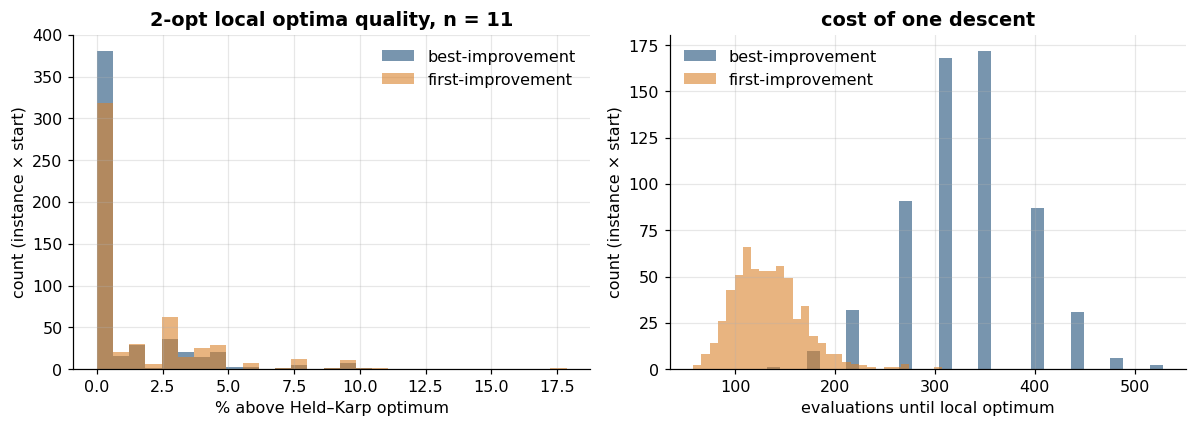

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(0, max(max(res["best"]["gap"]), max(res["first"]["gap"])), 30)
for rule, col in (("best", PALETTE["blue"]), ("first", PALETTE["orange"])):
    axes[0].hist(res[rule]["gap"], bins=bins, alpha=0.6, color=col, label=f"{rule}-improvement")
    axes[1].hist(res[rule]["evals"], bins=30, alpha=0.6, color=col, label=f"{rule}-improvement")
axes[0].set(xlabel="% above Held–Karp optimum", ylabel="count (instance × start)",
            title=f"2-opt local optima quality, n = {N_CITIES}")
axes[1].set(xlabel="evaluations until local optimum", ylabel="count (instance × start)", title="cost of one descent")
axes[0].legend(); axes[1].legend()
fig.tight_layout(); savefig("w1_two_opt_vs_exact.png"); plt.show()

The numbers above show the classic trade-off: best-improvement pays a full neighbourhood scan per move and needs more
evaluations per descent, but here it ends in the global optimum more often; first-improvement is cheaper per descent
and, with a random scan order, more diverse. With restarts, the relevant quantity is quality *per evaluation*, and
neither rule is uniformly better (Hansen & Mladenović 2006 give a careful comparison for the TSP). A single 2-opt descent is already close to optimal on
these small instances but ends in a *non*-global local optimum a substantial fraction of the time; this is exactly the
gap that the escape mechanisms of Weeks 2–3 (annealing, tabu memory, perturbation) are designed to close.

## 5. Random search vs random-restart hill climbing at equal budgets

**Pure random search** samples $x \sim \mathrm{Unif}(S)$ repeatedly; **random-restart hill climbing (RRHC)** runs
independent descents from uniform starts until the budget is exhausted. Both are counted with a
`BudgetedObjective`. For RRHC we evaluate candidates by full tour length, so each assessed neighbour costs one
evaluation, exactly as for random search.

In [7]:
def random_search(f, sampler, rng):
    try:
        while True:
            f(sampler(rng))
    except BudgetExhausted:
        pass

def rrhc_two_opt(f, n, rng):
    """Random-restart best-improvement 2-opt; every neighbour is assessed through the budgeted objective."""
    try:
        while True:
            t = rng.permutation(n); ft = f(t)
            while True:
                nbrs = np.array([two_opt_move(t, i, j) for (i, j) in two_opt_moves(n)])
                vals = f(nbrs)
                k = int(np.argmin(vals))
                if vals[k] >= ft - 1e-12:
                    break
                t, ft = nbrs[k], vals[k]
    except BudgetExhausted:
        pass

BUDGET, N_RUNS, N_CITIES2 = 3000, 20, 11
grid = np.unique(np.logspace(0, np.log10(BUDGET), 60).astype(int))
curves = {"random search": [], "RRHC (2-opt)": []}
final = {k: [] for k in curves}
for r in range(N_RUNS):
    irng = np.random.default_rng(2000 + r)
    _, D = random_euclidean_tsp(N_CITIES2, irng)
    L_opt, _ = held_karp(D)
    for name in curves:
        F = BudgetedObjective(lambda T: np.array([tour_length(t, D) for t in np.atleast_2d(T)]), BUDGET)
        arng = np.random.default_rng(3000 + r)
        if name == "random search":
            random_search(F, lambda g: g.permutation(N_CITIES2), arng)
        else:
            rrhc_two_opt(F, N_CITIES2, arng)
        ev, best = F.trace()
        idx = np.searchsorted(ev, grid, side="right") - 1
        curves[name].append(100 * (best[idx] - L_opt) / L_opt)
        final[name].append(100 * (F.best_f - L_opt) / L_opt)
for name in curves:
    q1, med, q3 = np.percentile(final[name], [25, 50, 75])
    print(f"{name:14s} after {BUDGET} evals: % above optimum median {med:.2f} [IQR {q1:.2f}, {q3:.2f}], "
          f"runs at optimum {np.mean(np.array(final[name]) < 1e-9):.2f}")
check_true(np.median(final["RRHC (2-opt)"]) < np.median(final["random search"]),
           "RRHC beats random search at equal budget (median over 20 instances)")

random search  after 3000 evals: % above optimum median 19.34 [IQR 14.72, 25.01], runs at optimum 0.00
RRHC (2-opt)   after 3000 evals: % above optimum median 0.00 [IQR 0.00, 0.00], runs at optimum 1.00
[PASS] RRHC beats random search at equal budget (median over 20 instances)


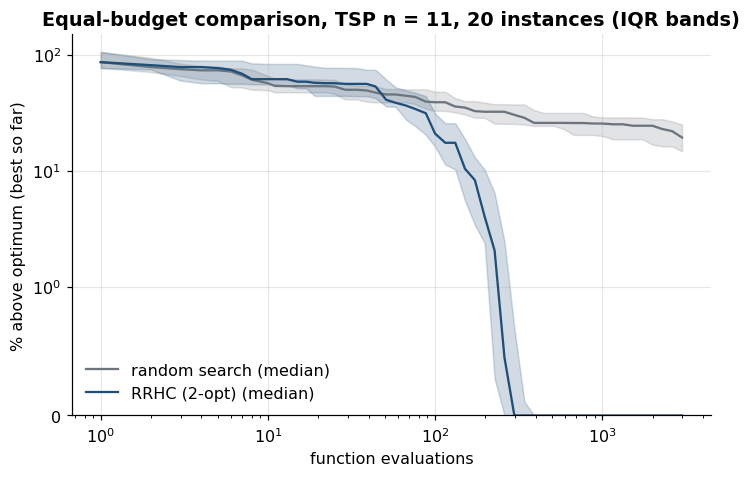

In [8]:
fig, ax = plt.subplots()
for name, col in (("random search", PALETTE["grey"]), ("RRHC (2-opt)", PALETTE["blue"])):
    C = np.array(curves[name])
    q1, med, q3 = np.percentile(C, [25, 50, 75], axis=0)
    ax.plot(grid, med, color=col, label=f"{name} (median)")
    ax.fill_between(grid, q1, q3, color=col, alpha=0.2)
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=1); ax.set_ylim(0, 150)
ax.set(xlabel="function evaluations", ylabel="% above optimum (best so far)",
       title=f"Equal-budget comparison, TSP n = {N_CITIES2}, {N_RUNS} instances (IQR bands)")
ax.legend(); savefig("w1_random_vs_rrhc.png"); plt.show()

## 6. Basins of attraction, measured exhaustively

For a deterministic descent $h: S \to S$ (here best-improvement bit-flip hill climbing), the **basin** of a local
optimum $x^\ast$ is $B(x^\ast) = \lbrace x : h(x) = x^\ast\rbrace$. If starts are uniform, one descent ends at the global
optimum with probability $p = |B(x^\ast_{\mathrm{glob}})| / |S|$, and the number of restarts until success is geometric
with mean $1/p$.

Test instance: a **Sherrington–Kirkpatrick spin glass** (Sherrington & Kirkpatrick 1975) with a small random field,
$f(x) = -\tfrac12 s^\top J s - h^\top s$ with spins $s = 2x - 1 \in \lbrace -1, 1\rbrace^{14}$, $J_{ij} = J_{ji} \sim \mathcal{N}(0,1)$,
$J_{ii} = 0$, $h_i \sim \mathcal{N}(0, 0.3^2)$ (the field breaks the $s \mapsto -s$ symmetry). Substituting $s = 2x-1$ turns
it into a QUBO, the model behind max-cut and quantum-annealing formulations. $|S| = 16384$, so we can compute the
descent map for **every** start with vectorised pointer jumping, and then check the prediction with an independent
simulation of hill climbing.

In [9]:
NB = 14
J = np.triu(rng.standard_normal((NB, NB)), 1); J = J + J.T
hfield = 0.3 * rng.standard_normal(NB)
states = np.arange(2**NB)
SPINS = 2.0 * ((states[:, None] >> np.arange(NB)) & 1) - 1.0             # spin i of state s (bit i -> +-1)
F_all = -0.5 * np.einsum("si,ij,sj->s", SPINS, J, SPINS) - SPINS @ hfield
NBR = states[:, None] ^ (1 << np.arange(NB))[None, :]                   # the 14 bit-flip neighbours
nbr_vals = F_all[NBR]
best_nbr = NBR[states, np.argmin(nbr_vals, axis=1)]
step = np.where(nbr_vals.min(axis=1) < F_all, best_nbr, states)        # one best-improvement step
attractor = step.copy()
while True:                                                             # pointer jumping: h = step^infinity
    nxt = attractor[attractor]
    if np.array_equal(nxt, attractor):
        break
    attractor = nxt

local_opt = np.flatnonzero(np.all(nbr_vals > F_all[:, None], axis=1))  # definition: no neighbour at least as good
optima, basin = np.unique(attractor, return_counts=True)
g = int(np.argmin(F_all))
check_true(np.array_equal(np.sort(optima), local_opt), "attractors of the descent = local optima by definition")
check_close(basin.sum(), 2**NB, "basins partition the search space", atol=0)
p_glob = basin[optima == g][0] / 2**NB
order = np.argsort(F_all[optima])
print(f"{len(optima)} local optima; global optimum f* = {F_all[g]:.3f} has basin {basin[optima == g][0]} states "
      f"(p = {p_glob:.4f}); largest basin belongs to rank {int(np.where(order == np.argmax(basin))[0][0]) + 1} of {len(optima)}")

[PASS] attractors of the descent = local optima by definition
[PASS] basins partition the search space: got 16384, expected 16384
11 local optima; global optimum f* = -36.659 has basin 5252 states (p = 0.3206); largest basin belongs to rank 1 of 11


In [10]:
def sk_energy(x, J, h):
    s = 2.0 * np.atleast_2d(x) - 1.0
    return -0.5 * np.einsum("ki,ij,kj->k", s, J, s) - s @ h

def hill_climb_bits(x, J, h):
    """Independent implementation: best-improvement bit flips on bit vectors, energy evaluated directly."""
    x = x.astype(float).copy(); fx = sk_energy(x, J, h)[0]
    while True:
        cands = np.repeat(x[None], len(x), axis=0); idx = np.arange(len(x))
        cands[idx, idx] = 1 - cands[idx, idx]
        vals = sk_energy(cands, J, h)
        k = int(np.argmin(vals))
        if vals[k] >= fx:
            return x
        x, fx = cands[k], vals[k]

R = 1500
hits = 0
for _ in range(R):
    xf = hill_climb_bits(rng.integers(0, 2, NB), J, hfield)
    hits += int(xf @ (1 << np.arange(NB))) == g
p_hat = hits / R
se = np.sqrt(p_glob * (1 - p_glob) / R)
print(f"simulated success rate of one descent: {p_hat:.4f}  (exhaustive prediction {p_glob:.4f}, binomial s.e. {se:.4f})")
check_close(p_hat, p_glob, "RRHC single-descent success rate = global basin fraction", atol=4 * se, rtol=0)
print(f"expected restarts to hit the global optimum: 1/p = {1 / p_glob:.1f}")

simulated success rate of one descent: 0.3300  (exhaustive prediction 0.3206, binomial s.e. 0.0120)
[PASS] RRHC single-descent success rate = global basin fraction: got 0.33, expected 0.320557
expected restarts to hit the global optimum: 1/p = 3.1


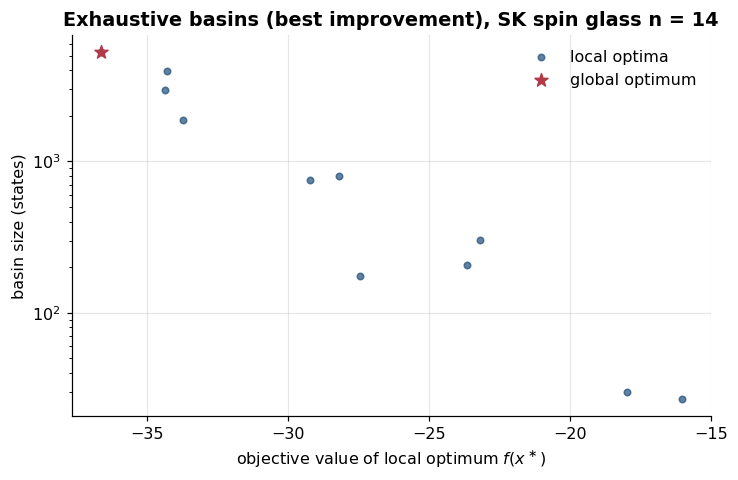

Spearman correlation(f(x*), basin size) = -0.95 (p = 1.1e-05)
[PASS] lower (better) local optima have significantly larger basins


In [11]:
fig, ax = plt.subplots()
ax.scatter(F_all[optima], basin, s=18, color=PALETTE["blue"], alpha=0.7, label="local optima")
ax.scatter([F_all[g]], [basin[optima == g][0]], s=80, color=PALETTE["red"], marker="*", label="global optimum")
ax.set_yscale("log")
ax.set(xlabel="objective value of local optimum $f(x^\\ast)$", ylabel="basin size (states)",
       title=f"Exhaustive basins (best improvement), SK spin glass n = {NB}")
ax.legend(); savefig("w1_basins_spin_glass.png"); plt.show()
from scipy.stats import spearmanr
rho, pval = spearmanr(F_all[optima], basin)
print(f"Spearman correlation(f(x*), basin size) = {rho:.2f} (p = {pval:.1e})")
check_true(rho < 0 and pval < 0.05, "lower (better) local optima have significantly larger basins")

## 7. Hamming cliffs: standard binary vs Gray coding

Encode an integer $i \in \lbrace 0, \ldots, 2^k-1\rbrace$ with $k$ bits and search with bit flips. In standard binary,
consecutive integers can differ in many bits ($127 = 01111111_2$ and $128 = 10000000_2$ differ in all 8): a
**Hamming cliff**. The reflected Gray code $\mathrm{gray}(i) = i \oplus (i \gg 1)$ (Gray 1953 patent) maps consecutive
integers to strings at Hamming distance 1.

**Proposition.** If $f$ is strictly unimodal on the integer line, then $f \circ \mathrm{gray}^{-1}$ has exactly one local
minimum under bit flips. *Proof.* Any non-optimal $i$ has an integer neighbour $i\pm1$ that is strictly better; its Gray
code is a bit-flip neighbour of $\mathrm{gray}(i)$, so $i$ is not a local minimum. $\square$

Standard binary gives no such guarantee. We count local minima of $f(i) = (i - t)^2$ for **every** target $t$
with $k = 8$. (Whitley 1999 analyses the general Gray-vs-binary trade-off; by NFL neither code wins on all functions.)

In [12]:
K = 8
ints = np.arange(2**K)
gray = ints ^ (ints >> 1)
gray_inv = np.empty_like(gray); gray_inv[gray] = ints            # decode: genotype -> integer
popcount = np.vectorize(lambda v: bin(int(v)).count("1"))
check_true(np.all(popcount(gray[1:] ^ gray[:-1]) == 1), "Gray code: consecutive integers differ in exactly one bit")
print("Hamming distance 127 <-> 128: binary", popcount(127 ^ 128), "| Gray", popcount(gray[127] ^ gray[128]))

def n_local_minima(values):                          # values indexed by genotype
    nb = ints[:, None] ^ (1 << np.arange(K))[None, :]
    return int(np.sum(np.all(values[nb] >= values[:, None], axis=1)))   # no strictly better neighbour

counts_bin, counts_gray = [], []
for t in ints:
    counts_bin.append(n_local_minima((ints - t) ** 2.0))            # genotype g decodes to integer g
    counts_gray.append(n_local_minima((gray_inv - t) ** 2.0))       # genotype g decodes to gray^{-1}(g)
counts_bin, counts_gray = np.array(counts_bin), np.array(counts_gray)
check_true(np.all(counts_gray == 1), "Gray coding: every one of the 256 unimodal targets has a single local minimum")
print(f"standard binary: {np.mean(counts_bin > 1) * 100:.1f}% of targets have false local minima; "
      f"max number of local minima = {counts_bin.max()}")

[PASS] Gray code: consecutive integers differ in exactly one bit
Hamming distance 127 <-> 128: binary 8 | Gray 1
[PASS] Gray coding: every one of the 256 unimodal targets has a single local minimum
standard binary: 99.2% of targets have false local minima; max number of local minima = 8


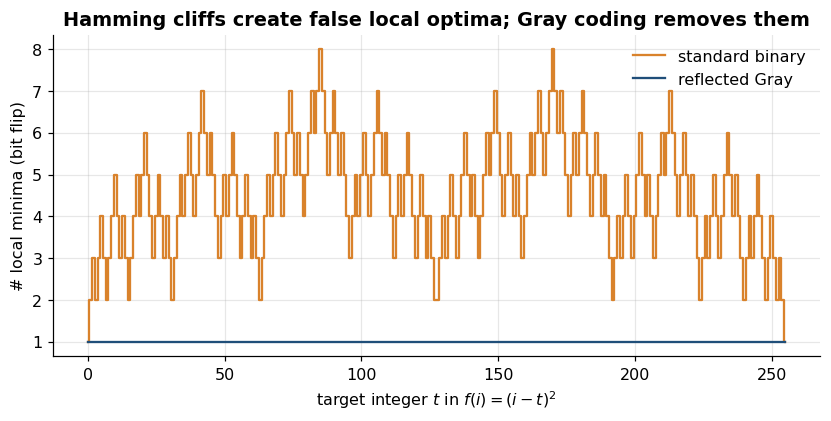

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.step(ints, counts_bin, where="mid", color=PALETTE["orange"], label="standard binary")
ax.step(ints, counts_gray, where="mid", color=PALETTE["blue"], label="reflected Gray")
ax.set(xlabel="target integer $t$ in $f(i)=(i-t)^2$", ylabel="# local minima (bit flip)",
       title="Hamming cliffs create false local optima; Gray coding removes them")
ax.legend(); savefig("w1_gray_vs_binary.png"); plt.show()

## Key takeaways
- A landscape is defined by representation, neighbourhood *and* objective; changing the encoding (binary → Gray) or the
  neighbourhood changes which points are local optima.
- Neighbourhood sizes ($n$, $\binom{n}{2}$, $(n-1)^2$, $n(n-3)/2$) were verified by enumeration; delta evaluation makes
  2-opt moves $O(1)$.
- 2-opt descents on 11-city instances end within a few percent of the Held–Karp optimum but hit it only part of the time;
  first- and best-improvement trade move quality against scan cost.
- At equal evaluation budgets, random-restart hill climbing dominates pure random search on the TSP.
- Exhaustive basins turn "how often does a restart succeed?" into an exact number $p$; simulation matched it within
  binomial error, and fitter optima had larger basins.
- Gray coding guarantees a single local minimum for 1-D unimodal functions; standard binary does not.

## Exercises
1. ★ Prove that for $N \subseteq N'$ every $N'$-local optimum is an $N$-local optimum, and give a TSP example where a
   2-opt local optimum is not 3-opt locally optimal.
2. ★ Show that swap moves on permutations connect $\mathfrak{S}_n$ with diameter $n-1$, and that 2-opt connects all
   tours of a symmetric TSP.
3. ★★ Implement Or-opt (move a segment of 1–3 cities) with delta evaluation and compare its local optima quality and
   cost against 2-opt on the same Held–Karp-validated instances.
4. ★★ Recompute the exhaustive basins of Section 6 for *first*-improvement with a fixed scan order. Are the local
   optima the same? Are the basins? Explain.
5. ★★ Prove that if a single descent succeeds with probability $p$, RRHC with budget $B$ and descents of cost at
   most $c$ succeeds with probability at least $1-(1-p)^{\lfloor B/c\rfloor}$; check the bound against Section 6.
6. ★★★ Construct a *multimodal* function on $\lbrace 0,\ldots,255\rbrace$ for which standard binary induces
   *fewer* bit-flip local minima than Gray coding. Then argue, by an NFL-style counting argument over all functions,
   why such functions must exist, and compare with Whitley's (1999) analysis of Gray vs binary encodings.